In [1]:
import pandas as pd
import os.path as op
import numpy as np
from os import listdir
#import pingouin
import matplotlib.pyplot as plt
import seaborn as sns


bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
bids_folder_behav ='/Users/mrenke/data/ds-stressrisk'

#bids_folder = bids_folder_behav
subFolders = [f[4:] for f in listdir(bids_folder) if f[0:3] == 'sub']

from stress_risk.utils.data import get_data
df = get_data(bids_folder = bids_folder_behav)
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)


/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from stress_risk.utils import Subject
from nilearn import image
from nilearn.maskers import NiftiMasker
from stress_risk.utils.data import add_cond2df

roi='NPC_R'
key = 'encoding_model.cv.denoise.retroicor'

# prep. col names for df in next step
parameter_names = ['mu','sd','amplitude','baseline']
d1 = {}
for col_name in parameter_names:
    d1[col_name] = col_name  + f'_1'
d2 = {}
for col_name in parameter_names:
    d2[col_name] = col_name  + f'_2'

pars_s = []
for subject in subFolders:
    sub = Subject(subject, bids_folder)

    # get average cv-r2 map from session 1 for voxel selection
    ses=1
    fn = op.join(bids_folder, 'derivatives', key, f'sub-{sub.subject}', f'ses-{ses}','func', f'sub-{sub.subject}_ses-{ses}_desc-cvr2.optim_space-T1w_pars.nii.gz')
    im_cvr2 = image.load_img(fn)
    mask = sub.get_volume_mask(roi=roi, session=ses, epi_space=True) # anat from session1
    masker = NiftiMasker(mask_img=mask)
    cv_r2_1 = pd.DataFrame(masker.fit_transform(im_cvr2))

    ses=2
    fn = op.join(bids_folder, 'derivatives', key, f'sub-{sub.subject}', f'ses-{ses}','func', f'sub-{sub.subject}_ses-{ses}_desc-cvr2.optim_space-T1w_pars.nii.gz')
    im_cvr2 = image.load_img(fn)
    mask = sub.get_volume_mask(roi=roi, session=ses, epi_space=True) # anat from session1
    masker = NiftiMasker(mask_img=mask)
    cv_r2_2 = pd.DataFrame(masker.fit_transform(im_cvr2))

    #r2_mask = (cv_r2_1 > 0.0) or (cv_r2_2 > 0.0)
    r2_mask = (cv_r2_1 > 0.0) | (cv_r2_2 > 0.0) # bitwise operator
    r2_mask = r2_mask.to_numpy().T
    n_voxels = r2_mask.sum()

    # get params
    pars1 = sub.get_prf_parameters_volume(session=1, cross_validated=False,denoise=True, retroicor=True,smoothed=True, pca_confounds=False,roi=roi)
    pars1 =pars1.rename(mapper=d1,axis=1)
    pars1 = pars1[r2_mask] #

    pars2 = sub.get_prf_parameters_volume(session=2, cross_validated=False,denoise=True, retroicor=True,smoothed=True, pca_confounds=False,roi=roi)
    pars2 = pars2.rename(mapper=d2,axis=1)
    pars2 = pars2[r2_mask] #

    pars = pd.concat([pars1,pars2],axis=1)
    pars = pars.reset_index().rename(mapper={'index':'voxel_n'},axis=1)
    pars['subject'] = int(sub.subject)

    pars = pars.set_index(['subject','voxel_n'])
    pars_s.append(pars)

pars_s = pd.concat(pars_s)  
pars_s = add_cond2df(pars_s)
      

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/image/image.py:756: FutureWarning: Image data has type int64, which may cause incompatibilities with other tools. This will error in NiBabel 5.0. This warning can be silenced by passing the dtype argument to Nifti1Image().
  return klass(data, affine, header=header)
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/image/image.py:756: FutureWarning: Image data has type int64, which may cause incompatibilities with other tools. This will error in NiBabel 5.0. This warning can be silenced by passing the dtype argument to Nifti1Image().
  return klass(data, affine, header=header)
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/image/image.py:756: FutureWarning: Image data has type int64, which may cause incompatibilities with other tools. This will error in NiBabel 5.0. This warning can be silenced by passing the dtype argument to Nifti1Image().
  retu

In [3]:
pars_s['mu_1_norm'] = np.exp(pars_s['mu_1']) # mode
pars_s['mu_2_norm'] = np.exp(pars_s['mu_2'])

#pars_s['sd_1_norm'] = np.sqrt(np.log(1 + (pars_s['sd_1']**2 / pars_s['mu_1']**2)))
#np.sqrt((np.exp(pars_s['sd_1']**2) - 1 ) * np.exp(2*pars_s['mu_1'] +pars_s['sd_1']**2 )) # chatGPT
pars_s['sd_1_norm'] = np.sqrt((1 - np.exp(pars_s['sd_1']**2)) * (np.exp(pars_s['mu_1']))**2 )
#pars_s['sd_2_norm'] = np.sqrt(np.log(1 + (pars_s['sd_2']**2 / pars_s['mu_2']**2)))

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


[(0.0, 50.0)]

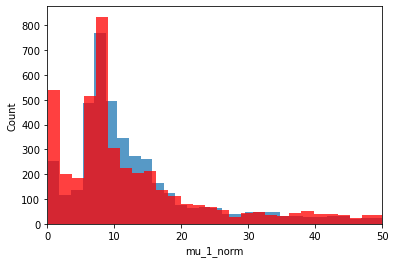

In [4]:
fig, ax = plt.subplots(1)
sns.histplot(pars_s['mu_1_norm'],label='session 1',ax=ax)
sns.histplot(pars_s['mu_2_norm'],label='session 2',ax=ax,color='red')
ax.set(xlim=(0, 50))

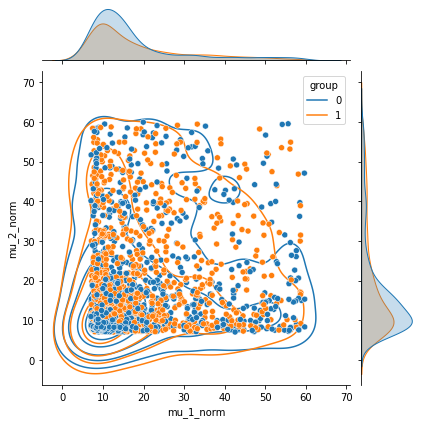

In [8]:
mu_thresh_up = 60
tmp = pars_s[(pars_s['mu_1_norm'] < mu_thresh_up) & (pars_s['mu_2_norm'] < mu_thresh_up)]
mu_thresh_low = 7
tmp = tmp[(tmp['mu_1_norm'] >mu_thresh_low) & (tmp['mu_2_norm'] >mu_thresh_low)]

sd_thresh = 5
tmp = tmp[(tmp['sd_1'] < sd_thresh) & (tmp['sd_2'] < sd_thresh)]
sd_thresh_lower = 0.0
tmp = tmp[(tmp['sd_1'] > sd_thresh_lower) & (tmp['sd_2'] > sd_thresh_lower)]

#g = sns.jointplot(data=tmp,x='mu_1_norm',y='mu_2_norm',kind="kde", hue='group') # ,kind='kde'

g = sns.jointplot(data=tmp, x="mu_1_norm", y="mu_2_norm", hue='group')
g.plot_joint(sns.kdeplot, hue='group', zorder=0, levels=6)
#g.plot_marginals(sns.rugplot, color="r", height=-.15, clip_on=False)

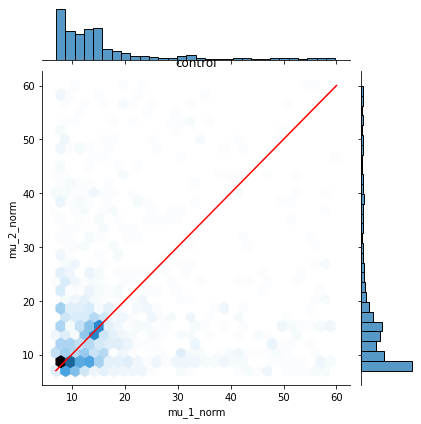

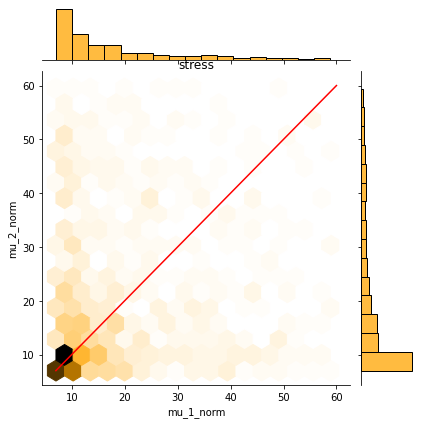

In [9]:
kind = 'hex'
g1=sns.jointplot(data=tmp[tmp['group'] == 0],x='mu_1_norm',y='mu_2_norm',kind=kind)
g1.ax_joint.set_title('control', pad=5)
g1.ax_joint.plot(np.linspace(mu_thresh_low, mu_thresh_up), np.linspace(mu_thresh_low, mu_thresh_up), 'r-')
g2=sns.jointplot(data=tmp[tmp['group'] == 1],x='mu_1_norm',y='mu_2_norm',kind=kind,color='orange')
g2.ax_joint.set_title('stress',pad=-10)
g2.ax_joint.plot(np.linspace(mu_thresh_low, mu_thresh_up), np.linspace(mu_thresh_low, mu_thresh_up), 'r-')




In [24]:
tmp_long = pd.melt(tmp.reset_index(), id_vars=['subject'], value_vars=['mu_1_norm', 'mu_2_norm'], var_name='session', value_name='mu_norm')
tmp_long['session'] = tmp_long['session'].replace({'mu_1_norm': 1, 'mu_2_norm': 2})
tmp_long = tmp_long.join(group_mapping, on='subject')

In [25]:
tmp_long

,subject,session,mu_norm,group
0,1,1,13.411621,0.0
1,1,1,27.473442,0.0
2,1,1,13.755172,0.0
3,1,1,13.613268,0.0
4,1,1,13.936243,0.0
...,...,...,...,...
4325,61,2,19.707428,0.0
4326,61,2,19.299822,0.0
4327,61,2,17.630320,0.0
4328,61,2,22.636196,0.0


In [27]:
import pingouin as pg

pg.mixed_anova(data=tmp_long, dv='mu_norm', between='group', within='session', subject='subject')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,58.971214,1,48,58.971214,1.472430,0.230900,0.029763,NaN
1,session,1.333308,1,48,1.333308,0.105402,0.746851,0.002191,1.0
2,Interaction,5.395184,1,48,5.395184,0.426507,0.516824,0.008807,NaN
